In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
np.random.seed(42)

**BATTERY DEGRADATION MODEL**

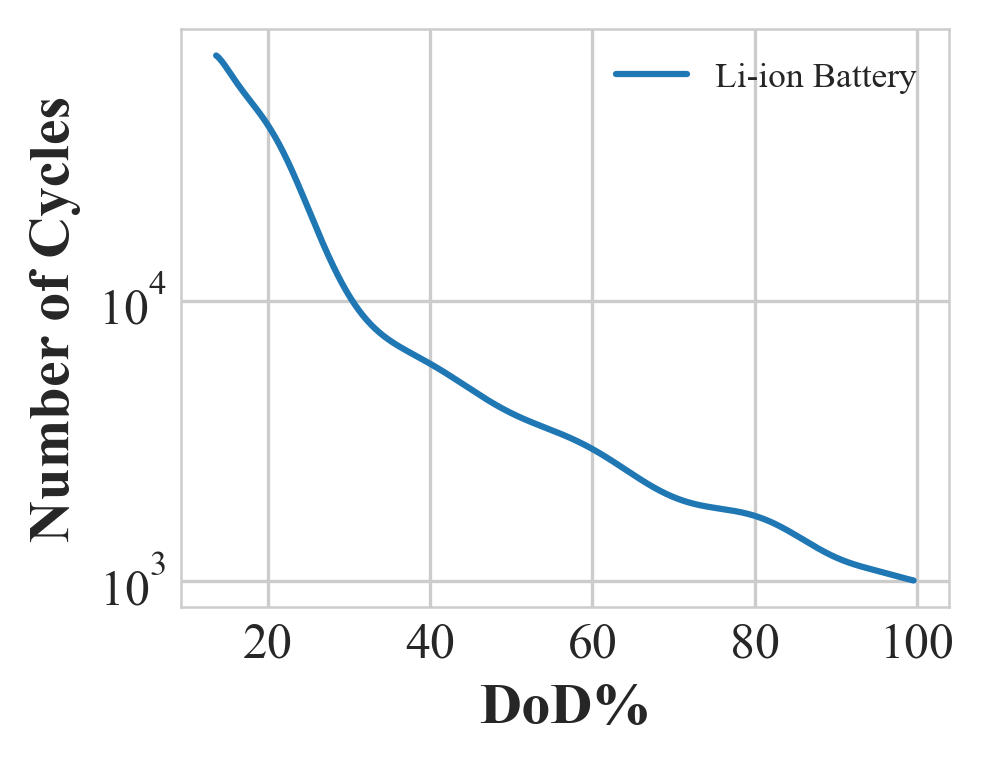

Polynomial degree: 14
Formula: y = exp(-1.329570e-21*x^14 + 1.107132e-18*x^13 + -4.179875e-16*x^12 + 9.465233e-14*x^11 + -1.433221e-11*x^10 + 1.531536e-09*x^9 + -1.188052e-07*x^8 + 6.777665e-06*x^7 + -2.849002e-04*x^6 + 8.754332e-03*x^5 + -1.929841e-01*x^4 + 2.951807e+00*x^3 + -2.956234e+01*x^2 + 1.733281e+02*x^1 + -4.373616e+02)


In [5]:
# Fit polynomial to DoD vs Cycles data

data = pd.read_csv(r"C:\Users\dzifa\OneDrive - University of Kentucky\Research (Thesis)\Experiments\datasets\dod_to_cycles.csv")   # <-- change filename to your CSV
x = data.iloc[:,0].to_numpy()
y = data.iloc[:,1].to_numpy()


# Take log of y
logy = np.log(y)

# Polynomial fit in log-space
degree = 14
coeffs = np.polyfit(x, logy, degree)
poly_log = np.poly1d(coeffs)

# Function in original scale
def fitted_func(xx):
    return np.exp(poly_log(xx))

# Plot
xx = np.linspace(min(x), max(x), 500)
# plt.scatter(x, y, label="Data", color="red")
plt.plot(xx, fitted_func(xx), label=f"Li-ion Battery")
plt.yscale("log")  # set log scale
plt.xlabel("DoD%")
plt.ylabel("Number of Cycles")
plt.legend()
plt.show()

# Print formula
formula_terms = " + ".join([f"{c:.6e}*x^{degree-i}" for i, c in enumerate(coeffs[:-1])])
formula = f"y = exp({formula_terms} + {coeffs[-1]:.6e})"

print("Polynomial degree:", degree)
print("Formula:", formula)

In [1293]:
y_fit = np.exp(poly_log(80.4214266144114))
print(y_fit)

1692.584480824884


-----------------------------------------------------------

PV Generation

In [3]:
pv_gen = pd.read_csv(r"C:\Users\dzifa\OneDrive - University of Kentucky\Research (Thesis)\Experiments\datasets\PV watts-y\pvwatts_hourly_8kw-exp.csv")
pv_gen.head(10)

,Month,Day,Hour,Beam Irradiance (W/m2),Diffuse Irradiance (W/m2),Ambient Temperature (C),Wind Speed (m/s),Albedo,Plane of Array Irradiance (W/m2),Cell Temperature (C),DC Array Output (W),AC System Output (W)
0,1,1,0,0,0,-4,2.0,0.14,0.000,-4.000,0.000,0.000
1,1,1,1,0,0,-5,1.8,0.14,0.000,-5.000,0.000,0.000
2,1,1,2,0,0,-5,1.8,0.14,0.000,-5.000,0.000,0.000
3,1,1,3,0,0,-5,1.7,0.14,0.000,-5.000,0.000,0.000
4,1,1,4,0,0,-6,1.6,0.14,0.000,-6.000,0.000,0.000
5,1,1,5,0,0,-6,1.5,0.14,0.000,-6.000,0.000,0.000
6,1,1,6,0,0,-6,1.5,0.14,0.000,-6.000,0.000,0.000
7,1,1,7,0,0,-5,1.9,0.14,0.000,-5.000,0.000,0.000
8,1,1,8,0,18,-4,2.7,0.14,16.683,-3.654,102.677,67.330
9,1,1,9,0,71,-2,3.6,0.14,68.031,-0.748,485.106,436.208


In [4]:
pv_gen = pv_gen[['Month', 'Day', 'Hour', 'AC System Output (W)']]
pv_gen.tail()

,Month,Day,Hour,AC System Output (W)
8755,12,31,19,0.0
8756,12,31,20,0.0
8757,12,31,21,0.0
8758,12,31,22,0.0
8759,12,31,23,0.0


In [5]:
pv_gen['AC System Output (W)'].value_counts()


AC System Output (W)
0.000       4524
6666.667      18
10.220         2
254.453        1
3218.226       1
            ... 
5458.050       1
5282.642       1
4591.822       1
3426.689       1
1364.264       1
Name: count, Length: 4219, dtype: int64

In [5]:
pv_gen["timestamp"] = pd.to_datetime({
    "year": 2025,
    "month": pv_gen["Month"],
    "day": pv_gen["Day"],
    "hour": pv_gen["Hour"]
})
pv_gen["Power_kW"] = pv_gen["AC System Output (W)"] / 1000.0

# Repeat each row 4 times (for 15-min intervals)
pv_gen_15min = pv_gen.loc[pv_gen.index.repeat(4)].copy().reset_index(drop=True)

# Create new timestamps spaced 15 minutes apart
pv_gen_15min["timestamp"] = pd.date_range(pv_gen["timestamp"].iloc[0],
                                   periods=len(pv_gen_15min),
                                   freq="15min")

# Compute energy in kWh for each 15-minute step
pv_gen_15min["Energy_kWh"] = pv_gen_15min["Power_kW"] * 0.25



In [6]:
pv_gen_15min.head(5)

,Month,Day,Hour,AC System Output (W),timestamp,Power_kW,Energy_kWh
0,1,1,0,0.0,2025-01-01 00:00:00,0.0,0.0
1,1,1,0,0.0,2025-01-01 00:15:00,0.0,0.0
2,1,1,0,0.0,2025-01-01 00:30:00,0.0,0.0
3,1,1,0,0.0,2025-01-01 00:45:00,0.0,0.0
4,1,1,1,0.0,2025-01-01 01:00:00,0.0,0.0


In [7]:
pv_gen_15min['Energy_kWh'].value_counts()

Energy_kWh
0.000000    18096
1.666667       72
0.002555        8
0.063613        4
0.804557        4
            ...  
1.364513        4
1.320661        4
1.147956        4
0.856672        4
0.341066        4
Name: count, Length: 4219, dtype: int64

In [7]:
pv_gen_15min = pv_gen_15min[['Month', 'Day', 'Hour', 'Energy_kWh']]

In [17]:
pv_gen_8kw = pv_gen_15min.copy()
pv_gen_4kw = pv_gen_15min.copy()
pv_gen_4kw = pv_gen_4kw.assign(#Power_kW = pv_gen_4kw["Power_kW"] * 0.5,
                                     Energy_kWh = pv_gen_4kw["Energy_kWh"] * 0.5)
pv_gen_12kw = pv_gen_15min.copy()
pv_gen_12kw = pv_gen_12kw.assign(#Power_kW = pv_gen_12kw["Power_kW"] * 1.5,
                                     Energy_kWh = pv_gen_12kw["Energy_kWh"] * 1.5)

pv_gen_0kw = pv_gen_15min.copy()
pv_gen_0kw = pv_gen_0kw.assign(#Power_kW = pv_gen_0kw["Power_kW"] * 0.0,
                                     Energy_kWh = pv_gen_0kw["Energy_kWh"] * 0.0)


In [21]:
pv_gen_8kw.isna().sum()

Month         0
Day           0
Hour          0
Energy_kWh    0
dtype: int64

In [ ]:
#save pv data to CSV
pv_gen_8kw.to_csv(r"C:\Users\dzifa\OneDrive - University of Kentucky\Research (Thesis)\Experiments\datasets\pv-generation\pvwatts_8kw_15min.csv", index=False)
pv_gen_4kw.to_csv(r"C:\Users\dzifa\OneDrive - University of Kentucky\Research (Thesis)\Experiments\datasets\pv-generation\pvwatts_4kw_15min.csv", index=False)
pv_gen_12kw.to_csv(r"C:\Users\dzifa\OneDrive - University of Kentucky\Research (Thesis)\Experiments\datasets\pv-generation\pvwatts_12kw_15min.csv", index=False)
pv_gen_0kw.to_csv(r"C:\Users\dzifa\OneDrive - University of Kentucky\Research (Thesis)\Experiments\datasets\pv-generation\pvwatts_0kw_15min.csv", index=False)

In [23]:
current_pv = pv_gen_4kw.copy()
current_pv_size = 4 # in kW

In [73]:
current_pv['Energy_kWh'].value_counts()

Energy_kWh
0.000000    18096
0.833333       72
0.001277        8
0.031807        4
0.402278        4
            ...  
0.682256        4
0.660330        4
0.573978        4
0.428336        4
0.170533        4
Name: count, Length: 4219, dtype: int64

**HOUSEHOLD LOAD**

In [56]:
home_size = 'large'
home_id = 15491
load = pd.read_parquet(f'datasets/home-timeseries/{home_size}_ky_homes/run{home_id}.parquet', engine='pyarrow')

load['home_id'] = home_id
load['home_size'] = home_size

In [57]:
load

,Time,Energy Use: Total,Energy Use: Net,Fuel Use: Electricity: Total,Fuel Use: Electricity: Net,End Use: Electricity: Heating,End Use: Electricity: Heating Fans/Pumps,End Use: Electricity: Heating Heat Pump Backup,End Use: Electricity: Heating Heat Pump Backup Fans/Pumps,End Use: Electricity: Cooling,...,Airflow: Mechanical Ventilation,Airflow: Natural Ventilation,Weather: Drybulb Temperature,Weather: Wetbulb Temperature,Weather: Relative Humidity,Weather: Wind Speed,Weather: Diffuse Solar Radiation,Weather: Direct Solar Radiation,home_id,home_size
0,None,kBtu,kBtu,kWh,kWh,kWh,kWh,kWh,kWh,kWh,...,cfm,cfm,F,F,%,mph,Btu/(hr*ft^2),Btu/(hr*ft^2),15491,large
1,2007-01-01T00:00:00,3.3693,3.3693,0.9874,0.9874,0.8122,0.0917,0.0,0.0,0.0,...,0.0,0.0,45.05,40.6806,69.5,6.0397,0.0,0.0,15491,large
2,2007-01-01T00:15:00,3.987,3.987,1.1685,1.1685,0.972,0.113,0.0,0.0,0.0,...,0.0,0.0,40.1,37.1747,77.0,4.0265,0.0,0.0,15491,large
3,2007-01-01T00:30:00,6.8912,6.8912,2.0196,2.0196,1.1486,0.1187,0.6382,0.0307,0.0,...,0.0,0.0,35.15,33.4105,84.5,2.0132,0.0,0.0,15491,large
4,2007-01-01T00:45:00,9.1361,9.1361,2.6775,2.6775,1.1204,0.0947,1.3243,0.0547,0.0,...,0.0,0.0,30.2,29.4028,92.0,0.0,0.0,0.0,15491,large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35036,2007-12-31T22:45:00,5.6131,5.6131,1.645,1.645,1.1752,0.1488,0.009,0.0005,0.0,...,0.0,0.0,33.8,31.3791,79.0,0.0,0.0,0.0,15491,large
35037,2007-12-31T23:00:00,5.1558,5.1558,1.511,1.511,1.1704,0.1432,0.1072,0.0062,0.0,...,0.0,0.0,33.35,31.1463,80.5,0.0,0.0,0.0,15491,large
35038,2007-12-31T23:15:00,5.4862,5.4862,1.6078,1.6078,1.1657,0.1377,0.2087,0.0117,0.0,...,0.0,0.0,32.9,30.9089,82.0,0.0,0.0,0.0,15491,large
35039,2007-12-31T23:30:00,5.8129,5.8129,1.7036,1.7036,1.1612,0.1325,0.309,0.0169,0.0,...,0.0,0.0,32.45,30.667,83.5,0.0,0.0,0.0,15491,large


In [58]:
load.dropna(inplace=True)
load.shape

(35040, 80)

In [59]:
# extract total energy consumption column with timestamps
total_consumption = load[['Time', 'Fuel Use: Electricity: Total', 'home_id', 'home_size']].copy()
total_consumption.rename(
    columns={'Fuel Use: Electricity: Total': 'total_consumption_kwh'},
    inplace=True
)
total_consumption.head()

,Time,total_consumption_kwh,home_id,home_size
1,2007-01-01T00:00:00,0.9874,15491,large
2,2007-01-01T00:15:00,1.1685,15491,large
3,2007-01-01T00:30:00,2.0196,15491,large
4,2007-01-01T00:45:00,2.6775,15491,large
5,2007-01-01T01:00:00,2.8313,15491,large


In [60]:
total_consumption.value_counts()

Time                 total_consumption_kwh  home_id  home_size
2007-01-01T00:00:00  0.9874                 15491    large        1
2007-01-01T00:15:00  1.1685                 15491    large        1
2007-01-01T00:30:00  2.0196                 15491    large        1
2007-01-01T00:45:00  2.6775                 15491    large        1
2007-01-01T01:00:00  2.8313                 15491    large        1
                                                                 ..
2007-12-31T22:45:00  1.645                  15491    large        1
2007-12-31T23:00:00  1.511                  15491    large        1
2007-12-31T23:15:00  1.6078                 15491    large        1
2007-12-31T23:30:00  1.7036                 15491    large        1
2007-12-31T23:45:00  1.7969                 15491    large        1
Name: count, Length: 35040, dtype: int64

In [ ]:
#save home load profiles to CSV
from pathlib import Path

base_dir = Path("datasets/home-timeseries")
parquet_files = list(base_dir.rglob("*.parquet"))
print(f"Found {len(parquet_files)} parquet files.")
for path in parquet_files:
    if not path.is_file():
        continue
    print(f"Processing {path}...")
    # infer home_size and home_id from the path
    home_size = path.parent.name
    if home_size.endswith("_ky_homes"):
        home_size = home_size.replace("_ky_homes", "")

    home_id = path.stem
    if home_id.startswith("run"):
        home_id = home_id.replace("run", "")

    df = pd.read_parquet(path, engine="pyarrow")
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    subset = pd.DataFrame()
    subset['month'] = current_pv['Month']
    subset['day'] = current_pv['Day']
    subset['hour'] = current_pv['Hour']
    subset['home_size'] = home_size
    subset['home_id'] = int(home_id) if home_id.isdigit() else home_id
    subset['total_consumption_kwh'] = df['Fuel Use: Electricity: Total']

    out_path = Path(f"datasets/home-load-profiles/{home_size}_home_{home_id}.csv")
    subset.to_csv(out_path, index=False)
    print(f"Saved {out_path}")

Found 30 parquet files.
Processing datasets\home-timeseries\large_ky_homes\run10033.parquet...
Saved datasets\home-load-profiles\large_home_10033.csv
Processing datasets\home-timeseries\large_ky_homes\run1050.parquet...
Saved datasets\home-load-profiles\large_home_1050.csv
Processing datasets\home-timeseries\large_ky_homes\run15491.parquet...
Saved datasets\home-load-profiles\large_home_15491.csv
Processing datasets\home-timeseries\large_ky_homes\run1617.parquet...
Saved datasets\home-load-profiles\large_home_1617.csv
Processing datasets\home-timeseries\large_ky_homes\run17683.parquet...
Saved datasets\home-load-profiles\large_home_17683.csv
Processing datasets\home-timeseries\large_ky_homes\run17858.parquet...
Saved datasets\home-load-profiles\large_home_17858.csv
Processing datasets\home-timeseries\large_ky_homes\run20379.parquet...
Saved datasets\home-load-profiles\large_home_20379.csv
Processing datasets\home-timeseries\large_ky_homes\run5649.parquet...
Saved datasets\home-load-pro

Combine datasets

In [61]:
print("Household load shape:", total_consumption.shape)
print("PV generation shape:", pv_gen.shape)

Household load shape: (35040, 4)
PV generation shape: (8760, 6)


In [74]:
# Combine datasets
household_energy_profile = pd.DataFrame()
household_energy_profile['month'] = current_pv['Month']
household_energy_profile['day'] = current_pv['Day']
household_energy_profile['hour'] = current_pv['Hour']
household_energy_profile['total_consumption_kwh'] = total_consumption['total_consumption_kwh']
household_energy_profile['home_id'] = total_consumption['home_id']
household_energy_profile['home_size'] = total_consumption['home_size']
household_energy_profile['pv_size'] = current_pv_size
# # convert w to kWh
household_energy_profile['pv_energy_gen_kWh'] = current_pv['Energy_kWh']

# remove rows with NaN values
household_energy_profile.dropna(inplace=True)
household_energy_profile.reset_index(drop=True)
household_energy_profile.tail(20)

,month,day,hour,total_consumption_kwh,home_id,home_size,pv_size,pv_energy_gen_kWh
35020,12,31,19,0.8191,15491.0,large,4,0.0
35021,12,31,19,1.2363,15491.0,large,4,0.0
35022,12,31,19,0.9272,15491.0,large,4,0.0
35023,12,31,19,1.1298,15491.0,large,4,0.0
35024,12,31,20,1.344,15491.0,large,4,0.0
35025,12,31,20,1.5723,15491.0,large,4,0.0
35026,12,31,20,1.6851,15491.0,large,4,0.0
35027,12,31,20,1.279,15491.0,large,4,0.0
35028,12,31,21,2.6471,15491.0,large,4,0.0
35029,12,31,21,3.7509,15491.0,large,4,0.0


In [75]:
household_energy_profile.tail(50)

,month,day,hour,total_consumption_kwh,home_id,home_size,pv_size,pv_energy_gen_kWh
34990,12,31,11,0.7836,15491.0,large,4,0.640921
34991,12,31,11,1.0922,15491.0,large,4,0.640921
34992,12,31,12,0.6976,15491.0,large,4,0.682256
34993,12,31,12,0.6594,15491.0,large,4,0.682256
34994,12,31,12,0.6126,15491.0,large,4,0.682256
34995,12,31,12,0.5745,15491.0,large,4,0.682256
34996,12,31,13,0.5362,15491.0,large,4,0.660330
34997,12,31,13,0.4978,15491.0,large,4,0.660330
34998,12,31,13,0.4594,15491.0,large,4,0.660330
34999,12,31,13,0.423,15491.0,large,4,0.660330


In [76]:
household_energy_profile.shape

(35039, 8)

In [77]:
household_energy_profile['pv_energy_gen_kWh'].value_counts()

pv_energy_gen_kWh
0.000000    18095
0.833333       72
0.001277        8
0.031807        4
0.402278        4
            ...  
0.682256        4
0.660330        4
0.573978        4
0.428336        4
0.170533        4
Name: count, Length: 4219, dtype: int64

In [78]:
print(f"Range of load: {household_energy_profile['total_consumption_kwh'].min()} - {household_energy_profile['total_consumption_kwh'].max()}")
print(f"Range of pv gen: {household_energy_profile['pv_energy_gen_kWh'].min()} - {household_energy_profile['pv_energy_gen_kWh'].max()}")

Range of load: 0.0819 - 7.7779
Range of pv gen: 0.0 - 0.833333375


In [79]:
household_energy_profile['total_consumption_kwh'] = household_energy_profile['total_consumption_kwh'].astype('float64')
print(household_energy_profile['total_consumption_kwh'].dtype, household_energy_profile['pv_energy_gen_kWh'].dtype)

float64 float64


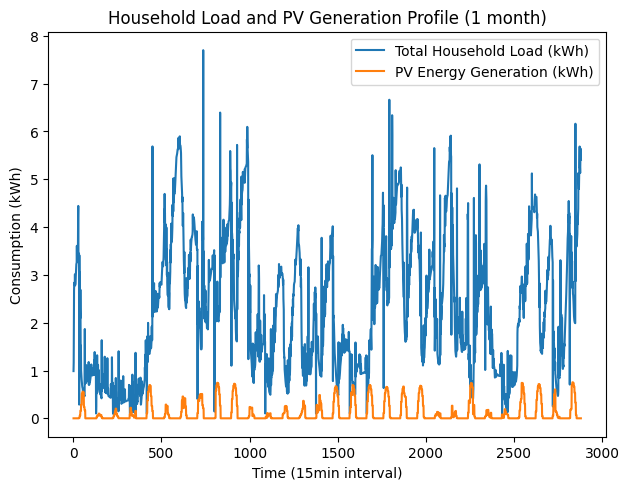

In [80]:
# PLOT FOR DURATION

duration = 24 * 30 * 4 # 1month
plt.figure()
plt.plot(household_energy_profile['total_consumption_kwh'][:duration], label='Total Household Load (kWh)')
plt.plot(household_energy_profile['pv_energy_gen_kWh'][:duration], label='PV Energy Generation (kWh)')
plt.xlabel('Time (15min interval)')
plt.ylabel('Consumption (kWh)')
plt.tight_layout()
plt.legend()
plt.title('Household Load and PV Generation Profile (1 month)')
plt.show()

**ELECTRICITY RATES**

In [ ]:

import pandas as pd

# ================================
# Configuration
# ================================
on_peak_rate = 0.18473   # $/kWh
off_peak_rate = 0.08798  # $/kWh

# Start of the week (Monday 00:00 EDT)
start_time = "2025-01-01 00:00:00"
timezone = "America/New_York"

# ================================
# Helper function to determine rate
# ================================
def get_buying_rate(ts):
    day = ts.day_name()
    hour = ts.hour
    # Weekends: all hours are off-peak
    if day in ["Saturday", "Sunday"]:
        return off_peak_rate
    # Weekdays: 2 PM to 6 PM are on-peak
    elif 14 <= hour < 18:
        return on_peak_rate
    else:
        return off_peak_rate

def get_selling_rate(ts):
    day = ts.day_name()
    hour = ts.hour
    # Weekends: all hours are off-peak
    if day in ["Saturday", "Sunday"]:
        return off_peak_rate
    # Weekdays: 2 PM to 6 PM are on-peak
    elif 14 <= hour < 18:
        return on_peak_rate * 1.2
    else:
        return 0.8* off_peak_rate

# ================================
# Generate 15-minute interval data
# ================================
timestamps_15min = pd.date_range(
    start=start_time,
    periods=24 * 4 * 365,  # 4 intervals per hour × 24 hours × 365 days
    freq="15min"
)

buying_rates_15min = [get_buying_rate(ts) for ts in timestamps_15min]
selling_rates_15min = [get_selling_rate(ts) for ts in timestamps_15min]

electricity_rate_15min = pd.DataFrame({
    "month": pv_gen_15min['Month'],
     "day": pv_gen_15min['Day'],
     "hour": pv_gen_15min['Hour'],
    "energy_buying_price($/kWh)": buying_rates_15min,
    "energy_selling_price($/kWh)": selling_rates_15min
})

# Save 15-min data
electricity_rate_15min.to_csv("electricity_cost_profile_15min.csv", index=False)

print("✅ File generated:")
print(" - electricity_cost_profile_15min.csv (15-min intervals)")


✅ File generated:
 - weekly_energy_cost_profile_15min.csv (15-min intervals)


In [ ]:
electricity_rate_15min.tail(50)

,month,day,hour,energy_buying_price($/kWh),energy_selling_price($/kWh)
34990,12,31,11,0.08798,0.070384
34991,12,31,11,0.08798,0.070384
34992,12,31,12,0.08798,0.070384
34993,12,31,12,0.08798,0.070384
34994,12,31,12,0.08798,0.070384
34995,12,31,12,0.08798,0.070384
34996,12,31,13,0.08798,0.070384
34997,12,31,13,0.08798,0.070384
34998,12,31,13,0.08798,0.070384
34999,12,31,13,0.08798,0.070384


In [81]:
household_energy_profile['energy_buying_price($/kWh)'] = df_15min['energy_buying_price($/kWh)']
household_energy_profile['energy_selling_price($/kWh)'] = df_15min['energy_selling_price($/kWh)']
household_energy_profile

,month,day,hour,total_consumption_kwh,home_id,home_size,pv_size,pv_energy_gen_kWh,energy_buying_price($/kWh),energy_selling_price($/kWh)
1,1,1,0,0.9874,15491.0,large,4,0.0,0.08798,0.070384
2,1,1,0,1.1685,15491.0,large,4,0.0,0.08798,0.070384
3,1,1,0,2.0196,15491.0,large,4,0.0,0.08798,0.070384
4,1,1,1,2.6775,15491.0,large,4,0.0,0.08798,0.070384
5,1,1,1,2.8313,15491.0,large,4,0.0,0.08798,0.070384
...,...,...,...,...,...,...,...,...,...,...
35035,12,31,22,1.4202,15491.0,large,4,0.0,0.08798,0.070384
35036,12,31,23,1.6450,15491.0,large,4,0.0,0.08798,0.070384
35037,12,31,23,1.5110,15491.0,large,4,0.0,0.08798,0.070384
35038,12,31,23,1.6078,15491.0,large,4,0.0,0.08798,0.070384


In [ ]:

# out_path =f"datasets/home-energy-profile/{current_pv_size}kw_pv_{home_size}_home{home_id}_tou1.parquet"
# household_energy_profile.to_parquet(out_path, engine="pyarrow")
# print(f"Saved household_energy_profile to: {out_path}")

Saved household_energy_profile to: datasets/home-energy-profile/4kw_pv_large_home15491_tou1.parquet


In [1317]:
# six_hrs = 4*6
# start_date = "1,3,15"
# month, day, hour = start_date.split(",")
# data = household_energy_profile[(household_energy_profile["month"] == int(month)) & (household_energy_profile['day'] == int(day)) & (household_energy_profile['hour'] == int(hour))].index
# if not data.empty:
#     start_idx = data[0]
#     end_idx = start_idx + 24 #for 6hrs
#     p_load =  household_energy_profile['total_consumption_kwh'][start_idx:end_idx].values
#     p_pv = household_energy_profile['pv_energy_gen_kWh'][start_idx:end_idx].values
#     energy_buying_prices = household_energy_profile['energy_buying_price($/kWh)'][start_idx:end_idx].values
#     energy_selling_prices = household_energy_profile['energy_selling_price($/kWh)'][start_idx:end_idx].values


In [1318]:
# energy_selling_prices

In [1319]:
# p_load

In [ ]:
# pd.read_parquet('datasets/home-energy-profile/8kw_pv_small_home33_tou1.parquet', engine='pyarrow')

,month,day,hour,total_consumption_kwh,home_id,home_size,pv_size,pv_energy_gen_kWh,energy_buying_price($/kWh),energy_selling_price($/kWh)
1,1,1,0,0.0061,33.0,small,8,0.0,0.08798,0.070384
2,1,1,0,0.0185,33.0,small,8,0.0,0.08798,0.070384
3,1,1,0,0.0184,33.0,small,8,0.0,0.08798,0.070384
4,1,1,1,0.0183,33.0,small,8,0.0,0.08798,0.070384
5,1,1,1,0.0181,33.0,small,8,0.0,0.08798,0.070384
...,...,...,...,...,...,...,...,...,...,...
35035,12,31,22,0.0406,33.0,small,8,0.0,0.08798,0.070384
35036,12,31,23,0.0442,33.0,small,8,0.0,0.08798,0.070384
35037,12,31,23,0.0458,33.0,small,8,0.0,0.08798,0.070384
35038,12,31,23,0.0476,33.0,small,8,0.0,0.08798,0.070384
